# Sparse Cell Channel — Metrics Over Time (GM vs PP v2)

Comparison of GM (getMotion, zRatio=10) and PP v2 (Phase Persist, fixed).
Metrics computed on **foreground pixels only** (k=2), normalized to [0, 255].
Centroid detection: mean + 2σ within foreground mask, radius=5px.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

GM_CSV  = Path("/mnt/data21T_2/cyf/f260517/GM_mapped_v2_layer3/metrics.csv")
PP_CSV  = Path("/mnt/data21T_2/cyf/f260517/PP_baseline_l3/metrics.csv")
OUT_DIR = Path("/home/cyf/wbi/Virginia/code_for_paper/Fig3")

df_gm = pd.read_csv(GM_CSV)
df_pp = pd.read_csv(PP_CSV)
frames = df_gm["frame"].values

def smooth(series, window=5):
    return series.rolling(window, center=True, min_periods=1).mean()

c_gm = "#4DAF4A"
c_pp = "#2166AC"

print(f"GM:  {len(df_gm)} frames  |  PP v2: {len(df_pp)} frames")
print(f"Columns: {list(df_gm.columns)}")

GM:  200 frames  |  PP v2: 200 frames
Columns: ['frame', 'mem_RMSE', 'mem_GradNCC', 'mem_SSIM', 'mem_NCC', 'sp_RMSE', 'sp_GradNCC', 'sp_SSIM', 'sp_NCC']


Saved to sparse_GradNCC_GM_vs_PPv2.png


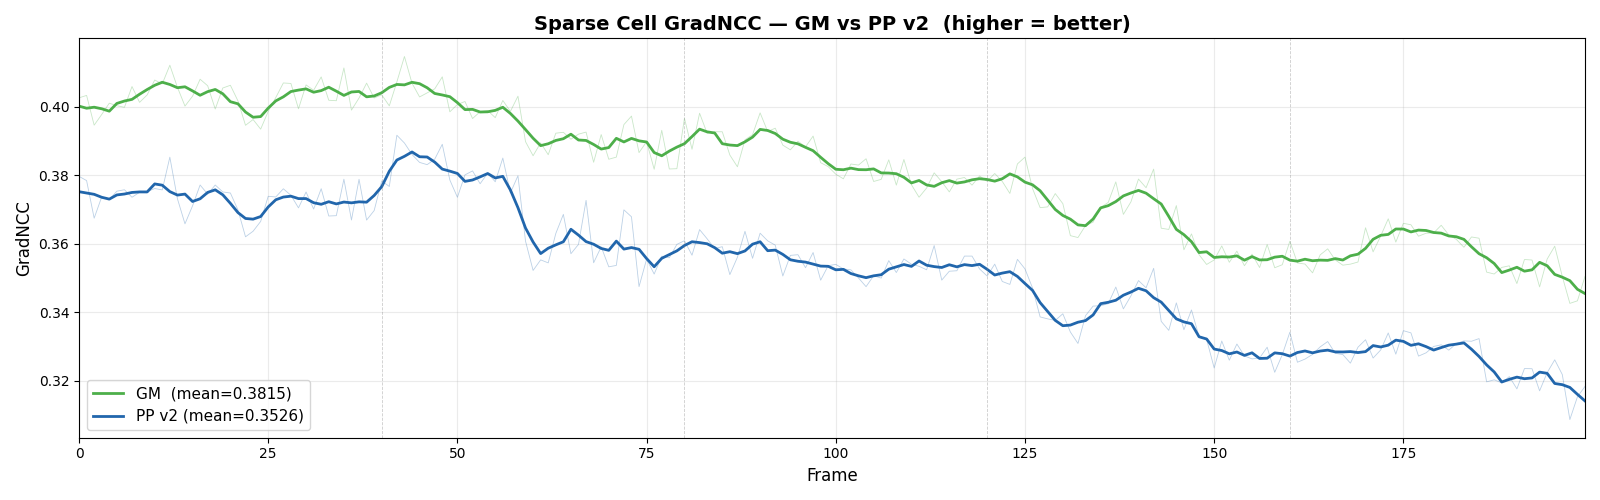

In [2]:
# ================================================================
# Figure 1: Sparse GradNCC — GM vs PP v2
# ================================================================
WINDOW = 5

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(frames, df_gm["sp_GradNCC"], color=c_gm, lw=0.6, alpha=0.3)
ax.plot(frames, df_pp["sp_GradNCC"], color=c_pp, lw=0.6, alpha=0.3)
ax.plot(frames, smooth(df_gm["sp_GradNCC"], WINDOW), color=c_gm, lw=2.0, label=f"GM  (mean={df_gm['sp_GradNCC'].mean():.4f})")
ax.plot(frames, smooth(df_pp["sp_GradNCC"], WINDOW), color=c_pp, lw=2.0, label=f"PP v2 (mean={df_pp['sp_GradNCC'].mean():.4f})")

for rf in [40, 80, 120, 160]:
    ax.axvline(x=rf, color="gray", lw=0.6, ls="--", alpha=0.4)

ax.set_ylabel("GradNCC", fontsize=12)
ax.set_xlabel("Frame", fontsize=12)
ax.set_title("Sparse Cell GradNCC — GM vs PP v2  (higher = better)", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="lower left")
ax.grid(True, alpha=0.25)
ax.set_xlim(0, 199)

fig.tight_layout()
fig.savefig(str(OUT_DIR / "sparse_GradNCC_GM_vs_PPv2.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved to sparse_GradNCC_GM_vs_PPv2.png")

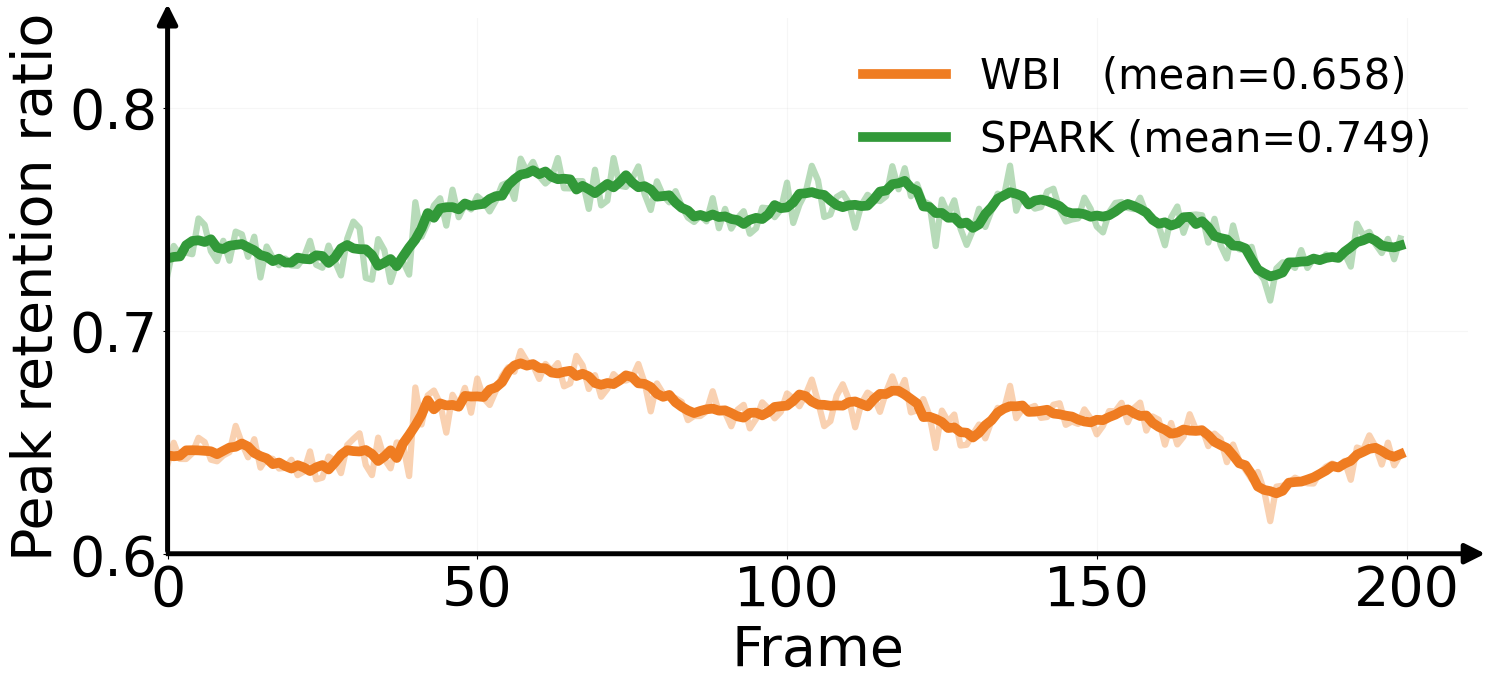

Saved to peak_ratio_15x15_wbi_vs_SPARK.pdf


In [3]:
# ================================================================
# Figure 4: Peak Retention Ratio (15×15 patch) — WBI vs SPARK
# 数据: exp/plots/sparse_cell_detection/v2/peak_ratio_cells_all200.csv
# 每帧 mean ± std (15×15)，图例/轴/箭头参数与 Fig2 (GradNCC) 一致
# ================================================================
WINDOW = 5
c_wbi   = "#ef7c21"   # orange
c_spark = "#329939"   # green

PEAK_CSV = Path("/home/cyf/wbi/Virginia/exp/plots/sparse_cell_detection/v2/peak_ratio_cells_all200.csv")
df_cells = pd.read_csv(PEAK_CSV)

# 每帧 mean ± std（15×15 patch）
g = df_cells.groupby("frame")
frames_p   = g["peak_ratio_GM_15"].mean().index.values
mean_wbi   = g["peak_ratio_GM_15"].mean().values
std_wbi    = g["peak_ratio_GM_15"].std().values
mean_spark = g["peak_ratio_PP_15"].mean().values
std_spark  = g["peak_ratio_PP_15"].std().values

sm_wbi   = smooth(pd.Series(mean_wbi), WINDOW).values
sm_spark = smooth(pd.Series(mean_spark), WINDOW).values

fig, ax = plt.subplots(figsize=(15, 7))

# 平滑（平均）曲线为主：粗线不透明，突出整体趋势
ax.plot(frames_p, sm_wbi, color=c_wbi, lw=7.0,
        label=f"WBI   (mean={mean_wbi.mean():.3f})")
ax.plot(frames_p, sm_spark, color=c_spark, lw=7.0,
        label=f"SPARK (mean={mean_spark.mean():.3f})")
# 每帧真实均值：较粗 + 中低透明度叠加在上层，展示帧间波动
ax.plot(frames_p, mean_wbi, color=c_wbi, lw=4.5, alpha=0.35)
ax.plot(frames_p, mean_spark, color=c_spark, lw=4.5, alpha=0.35)

ax.set_ylabel("Peak retention ratio", fontsize=40)
ax.set_xlabel("Frame", fontsize=40)
ax.tick_params(axis="both", labelsize=40)
ax.grid(True, alpha=0.1)
ax.set_xlim(0, 210)          # 横轴箭头末端超出数据末端 (199)
ax.set_ylim(0.60, 0.84)      # 曲线范围 0.64~0.78，上下留少量余量

# 只保留 X/Y 坐标轴，去掉上、右框线
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(3.0)
ax.spines["left"].set_linewidth(3.0)

# 坐标轴末端加箭头
ax.annotate("", xy=(1.015, 0), xycoords="axes fraction", xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color="black", lw=3.5, mutation_scale=30))
ax.annotate("", xy=(0, 1.032), xycoords="axes fraction", xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color="black", lw=3.5, mutation_scale=30))

ax.legend(fontsize=30, loc="upper right", frameon=False)
fig.tight_layout()
fig.savefig(str(OUT_DIR / "peak_ratio_15x15_wbi_vs_SPARK.pdf"), bbox_inches="tight")
plt.show()
print("Saved to peak_ratio_15x15_wbi_vs_SPARK.pdf")